# Auditoría 3 — ¿El último paso del reverso devuelve $x$ con ruido recién inyectado?

**Pregunta:** cerca de $t = 0$, ¿el sampler está devolviendo el último $x$ **con** ruido? (En muchas implementaciones, cerca de ese punto ya no se agrega más ruido.)

**Respuesta por lectura de código: sí, para los dos samplers estocásticos.**

- **Euler–Maruyama** (`samplers/euler_maruyama.py:59-64`): el `step` suma `g·√|dt|·Z` **incondicionalmente**, también en el último paso que aterriza en $t_{eps}$. No hay rama que anule el ruido al final.
- **El driver** (`samplers/base.py:161-172`): tras el último `step` hace `return x` tal cual. No existe la variante `x_mean` (el estado tras el drift, sin el ruido del paso) que Song et al. calculan en cada paso y **devuelven al final**; tampoco el `z = 0` del último paso de DDPM (Ho et al., alg. 2), ni un paso terminal de *denoising* por Tweedie ($x + \sigma^2 s$).
- **Predictor–corrector** (`samplers/predictor_corrector.py:119-134`): peor aún — el orden interno es predictor → corrector, así que **la última operación de toda la integración es un paso de Langevin con ruido** $\sqrt{2\varepsilon}\,Z$. (En el código de Song el orden es corrector → predictor y se devuelve el `x_mean` del último predictor.)
- **PF-ODE y Heun**: determinísticos — no inyectan ruido nunca. Lo de "vi que muchas veces no se agrega más ruido cerca de 0" corresponde a esas implementaciones de referencia (convención `x_mean` / `z=0`), que acá **no** está implementada.

Aparte del ruido del último paso hay un segundo efecto, común a los 4 samplers: la integración corta en $t_{eps} > 0$, así que hasta la marginal **ideal** $p_{t_{eps}}$ retiene el ruido del kernel $\sigma(t_{eps})$ ($\approx 0.0105$ para VP con el default $t_{eps}=10^{-3}$). Nadie "des-ruidea" al final.

Abajo: **(1)** magnitudes teóricas del ruido inyectado en el último paso vs el residual del kernel; **(2)** medición empírica con el **score analítico** de la mezcla (aísla el artefacto del sampler del error de la red): dispersión extra del $x$ devuelto vs la variante `x_mean`, barriendo `n_steps`; **(3)** lo mismo para PC.

In [1]:
# --- Setup: bootstrap de sys.path + imports + estilo de ploteo ---
import sys
import pathlib

_here = pathlib.Path.cwd()
_root = None
for _cand in (_here, *_here.parents):
    if (_cand / "src" / "diffusion").is_dir():
        _root = _cand
        break
if _root is None:
    raise RuntimeError(f"No encontré src/diffusion subiendo desde {_here}")
sys.path.insert(0, str(_root / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusion.sde import make_sde
from diffusion.samplers import make_sampler

torch.manual_seed(0)

C_A, C_B = "#2a78d6", "#008300"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
plt.rcParams.update({
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})
SDES = ["vp", "ve", "sub_vp"]
T_EPS = 1e-3   # default del sampler
print("raíz del paquete:", _root)

raíz del paquete: C:\Users\bravo\Facultad\calculo-estocastico\tp-final\diffusion-models


## Chequeo 1 — Magnitud teórica del ruido del último paso (EM)

El último paso de EM inyecta ruido fresco de desvío $g(t_{eps})\sqrt{|dt|}$ con $|dt| = (T - t_{eps})/n_{steps}$. Comparémoslo contra el ruido residual "legítimo" de la marginal en el punto de corte, $\sigma(t_{eps})$. La clave es $g$ en $t \to 0$: para VP $g(0) = \sqrt{\beta_{min}} \approx 0.32 \neq 0$, así que el último paso inyecta ruido de tamaño fijo $\propto \sqrt{|dt|}$; para VE y sub-VP $g(t_{eps})$ es chico y el efecto casi desaparece.

In [2]:
print(f"{'SDE':8s} {'g(t_eps)':>9s} {'sigma(t_eps)':>13s} | {'ruido últ. paso (n=500)':>24s} {'(n=50)':>8s}")
for name in SDES:
    sde = make_sde(name)
    t = torch.tensor([T_EPS])
    _, g = sde.sde(torch.ones(1, 2), t)
    _, std = sde.marginal_prob(torch.zeros(1, 2), t)
    inj_500 = g.item() * ((1.0 - T_EPS) / 500) ** 0.5
    inj_50 = g.item() * ((1.0 - T_EPS) / 50) ** 0.5
    print(f"{name:8s} {g.item():9.4f} {std.item():13.4f} | {inj_500:24.4f} {inj_50:8.4f}")
print()
print("VP con defaults: el ruido inyectado en el último paso (0.0155) SUPERA al residual del")
print("kernel en t_eps (0.0105) — el x devuelto lleva más ruido fresco que ruido 'legítimo'.")

SDE       g(t_eps)  sigma(t_eps) |  ruido últ. paso (n=500)   (n=50)
vp          0.3463        0.0105 |                   0.0155   0.0489
ve          0.0355        0.0101 |                   0.0016   0.0050
sub_vp      0.0051        0.0001 |                   0.0002   0.0007

VP con defaults: el ruido inyectado en el último paso (0.0155) SUPERA al residual del
kernel en t_eps (0.0105) — el x devuelto lleva más ruido fresco que ruido 'legítimo'.


## Chequeo 2 — Medición empírica (EM, score analítico): $x$ devuelto vs su propio `x_mean`

Con el score analítico de la mezcla bajo VP (sin red: aísla el artefacto del sampler), corremos EM guardando la trayectoria y reconstruimos la variante `x_mean` de Song **de la misma corrida**: el anteúltimo estado más el último paso *solo con drift*. La diferencia $x_{devuelto} - x_{mean}$ **es exactamente el ruido inyectado en el último paso** — medición pareada, sin ruido de Monte Carlo — y debe calzar con la teoría $g(t)\sqrt{|dt|}$.

Aclaración de honestidad estadística: la inflación de la dispersión intra-cluster que ese ruido produce en el toy es de ~0.3% de la varianza a `n_steps=500` — **por debajo del error muestral** con $N = 8000$, así que no intentamos medirla directamente; reportamos la magnitud del ruido inyectado (pareada, exacta) y la comparamos contra el residual legítimo $\sigma(t_{eps})$ y contra $\sigma_0$. En imágenes ese mismo desplazamiento por muestra aparece como grano de píxel.

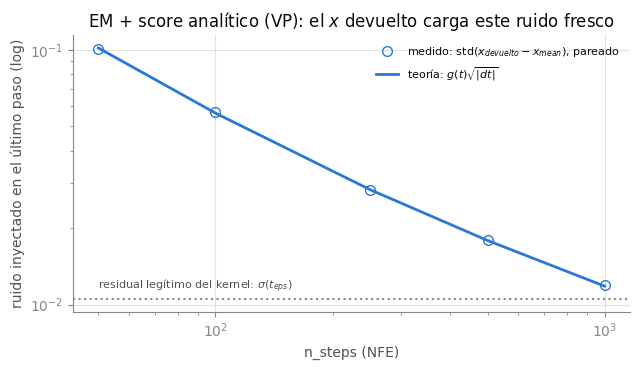

 n_steps  inyectado medido  teoría g·sqrt(dt)  / sigma(t_eps)  / sigma_0
      50            0.1005             0.1017            9.58      0.335
     100            0.0569             0.0564            5.43      0.190
     250            0.0282             0.0282            2.69      0.094
     500            0.0179             0.0179            1.71      0.060
    1000            0.0119             0.0118            1.14      0.040


In [3]:
K, RADIUS, SIGMA0 = 8, 5.0, 0.3
ang = np.linspace(0.0, 2.0 * np.pi, K, endpoint=False)
centers = torch.tensor(RADIUS * np.stack([np.cos(ang), np.sin(ang)], axis=1), dtype=torch.float32)
sde = make_sde("vp")

def analytic_mixture_score(x, t):
    t_flat = t.reshape(-1)
    alpha, std = sde.marginal_prob(torch.ones(x.shape[0], 2), t_flat)
    alpha = alpha[:, :1]
    v = (alpha * SIGMA0) ** 2 + std ** 2
    diff = x[:, None, :] - alpha[:, None, :] * centers[None, :, :]
    w = torch.softmax(-(diff ** 2).sum(-1) / (2.0 * v), dim=1)
    return -(w[:, :, None] * diff).sum(1) / v

def cluster_std(x):
    """Desvío por eje de los residuos al centro más cercano (pooled sobre ejes y clusters)."""
    idx = torch.cdist(x, centers).argmin(dim=1)
    resid = x - centers[idx]
    return resid.pow(2).mean().sqrt().item()

N = 8000
steps_sweep = [50, 100, 250, 500, 1000]
rows = []
for n_steps in steps_sweep:
    s = make_sampler("euler", sde, analytic_mixture_score, n_steps=n_steps, t_eps=T_EPS)
    gen = torch.Generator().manual_seed(11)
    x_ret, traj = s.sample(N, generator=gen, return_trajectory=True)
    # Variante x_mean (Song) DE LA MISMA corrida: último paso solo drift desde el anteúltimo estado.
    grid = s._time_grid()
    x_prev = traj[-2]
    t_prev = grid[-2].expand(N, 1)
    dt = (grid[-1] - grid[-2]).item()
    x_mean = x_prev + s._reverse_drift(x_prev, t_prev) * dt
    inj_measured = (x_ret - x_mean).std().item()               # = ruido del último paso (pareado)
    _, g_prev = sde.sde(x_prev[:1], grid[-2].reshape(1))
    inj_theory = g_prev.item() * abs(dt) ** 0.5
    rows.append((n_steps, inj_measured, inj_theory))

_, s_eps_t = sde.marginal_prob(torch.zeros(1, 2), torch.tensor([T_EPS]))
s_eps = s_eps_t.item()

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ns = [r[0] for r in rows]
ax.plot(ns, [r[1] for r in rows], "o", mfc="none", mec=C_A, ms=7,
        label="medido: std($x_{devuelto} - x_{mean}$), pareado")
ax.plot(ns, [r[2] for r in rows], "-", color=C_A, lw=2, label="teoría: $g(t)\\sqrt{|dt|}$")
ax.axhline(s_eps, color=MUTED, ls=":", lw=1.5)
ax.text(ns[0], s_eps * 1.1, "residual legítimo del kernel: $\\sigma(t_{eps})$", fontsize=8, color=INK2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("n_steps (NFE)")
ax.set_ylabel("ruido inyectado en el último paso (log)")
ax.set_title("EM + score analítico (VP): el $x$ devuelto carga este ruido fresco", color=INK)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

print(f"{'n_steps':>8s} {'inyectado medido':>17s} {'teoría g·sqrt(dt)':>18s} {'/ sigma(t_eps)':>15s} {'/ sigma_0':>10s}")
for n_steps, inj_m, inj_t in rows:
    print(f"{n_steps:8d} {inj_m:17.4f} {inj_t:18.4f} {inj_m / s_eps:15.2f} {inj_m / SIGMA0:10.3f}")

## Chequeo 3 — PC: la última operación es un paso de Langevin con ruido

Para PC la reconstrucción de `x_mean` no es directa (el `step` empaqueta predictor + correctores), así que medimos el ruido extra del $x$ devuelto y lo contrastamos con la estimación del ruido del corrector: $\varepsilon = 2(snr\,\|Z\|/\|s\|)^2$ y el ruido fresco por paso es $\sqrt{2\varepsilon}$. Con $\|s\|$ en $t_{eps}$ dominado por la suavidad del dato ($\approx 4$, no por $1/\sigma_t$), $\sqrt{2\varepsilon} \approx 0.1$ — **diez veces** el residual del kernel. La dinámica de Langevin contrae parte de ese ruido (es cuasi-estacionaria), pero el sesgo de ULA con ese $\varepsilon$ queda en las muestras.

In [4]:
# Estimación del epsilon del corrector en t_eps (mismas normas que usa el código).
gen = torch.Generator().manual_seed(5)
x_probe = centers[torch.randint(0, K, (4000,), generator=gen)] + SIGMA0 * torch.randn(4000, 2, generator=gen)
s_norm = analytic_mixture_score(x_probe, torch.full((4000,), T_EPS)).norm(dim=1).mean().item()
z_norm = torch.randn(4000, 2, generator=gen).norm(dim=1).mean().item()
snr = 0.16
eps_lang = 2.0 * (snr * z_norm / s_norm) ** 2
print(f"||s|| medio en t_eps = {s_norm:.3f} | epsilon Langevin = {eps_lang:.5f}"
      f" | ruido por paso corrector sqrt(2*eps) = {(2 * eps_lang) ** 0.5:.4f}")
print(f"(vs residual del kernel sigma(t_eps) = {s_eps:.4f})")
print()

# Inflación de la dispersión intra-cluster (sqrt(std_medido^2 - sigma_0^2)). Error muestral con
# N=8000: SE(var) ~ 0.001 => en estas unidades ±0.01-0.02; los valores de PC (~0.04-0.05) quedan
# claramente por encima, el de EM queda POR DEBAJO del error (consistente con su 0.018 teórico).
def extra_noise(x):
    dvar = cluster_std(x) ** 2 - SIGMA0 ** 2
    return max(dvar, 0.0) ** 0.5

for n_corr in (1, 2):
    s = make_sampler("pc", sde, analytic_mixture_score, n_steps=500, t_eps=T_EPS,
                     n_corrector=n_corr, snr=snr)
    x_ret = s.sample(N, generator=torch.Generator().manual_seed(11))
    print(f"PC n_steps=500, n_corrector={n_corr}: ruido extra medido = {extra_noise(x_ret):.4f}")

s = make_sampler("euler", sde, analytic_mixture_score, n_steps=500, t_eps=T_EPS)
x_ret = s.sample(N, generator=torch.Generator().manual_seed(11))
print(f"EM  n_steps=500 (referencia)  : ruido extra medido = {extra_noise(x_ret):.4f}"
      f"  <- bajo el error muestral (~0.01-0.02); su valor real es ~0.018 (chequeo 2)")

||s|| medio en t_eps = 4.138 | epsilon Langevin = 0.00473 | ruido por paso corrector sqrt(2*eps) = 0.0973
(vs residual del kernel sigma(t_eps) = 0.0105)



PC n_steps=500, n_corrector=1: ruido extra medido = 0.0506


PC n_steps=500, n_corrector=2: ruido extra medido = 0.0414


EM  n_steps=500 (referencia)  : ruido extra medido = 0.0027  <- bajo el error muestral (~0.01-0.02); su valor real es ~0.018 (chequeo 2)


## Conclusiones

1. **Confirmado: EM y PC devuelven el último $x$ con ruido recién inyectado.** EM suma `g·√|dt|·Z` también en el paso que aterriza en $t_{eps}$ y el driver hace `return x`; en PC la última operación de toda la integración es un Langevin con ruido. Las convenciones estándar que evitan esto — devolver `x_mean` (Song), $z=0$ en el último paso (DDPM), o un *denoise* terminal de Tweedie — **no están implementadas**. PF-ODE y Heun no tienen el problema (determinísticos).

2. **Magnitudes medidas (VP, score analítico):** el ruido del último paso de EM calza exacto con la teoría $g(t)\sqrt{|dt|}$ (el paso lo evalúa en $t_{eps}+dt$): $0.018$ a `n_steps=500` — **1.7× el residual legítimo del kernel** $\sigma(t_{eps}) \approx 0.0105$ — y crece como $1/\sqrt{n_{steps}}$: $0.10$ a `n=50` (9.6× el residual, 1/3 del $\sigma_0$ del dato). En PC el corrector final inyecta $\sqrt{2\varepsilon} \approx 0.097$ por paso; la contracción de Langevin absorbe una parte, pero la inflación intra-cluster medida queda en $\approx 0.04$–$0.05$ — bien por encima del error muestral y **el peor de los cuatro samplers en ruido terminal**. Para VE y sub-VP el término de EM es despreciable ($g(t_{eps}) \approx 0$), pero el corrector de PC les aplica igual.

3. **Impacto en el estudio:** en el toy 2D con $\sigma_0 = 0.3$ la inflación de EM a 500 pasos es ~0.4% de la varianza (invisible); la de PC no (~3%). Pero el punto estructural es que esto **sesga el Eje 2**: a NFE igualado, EM y PC cargan un ruido terminal que PF-ODE/Heun no tienen, y ese ruido es un artefacto de la convención del último paso, no una propiedad matemática del muestreo estocástico — Song lo elimina devolviendo `x_mean` precisamente para no penalizar a los samplers estocásticos. En imágenes (Fase 2) se manifiesta como grano de píxel, más fuerte a NFE bajo.

4. Qué hacer (decisión del autor, no implementado acá): devolver `x_mean` en el último paso de EM/PC (convención de Song — cambio local a `step`/driver), y/o un paso terminal de Tweedie $x + \sigma^2(t_{eps})\,s(x, t_{eps})$ común a los 4 samplers, que además remueve el residual $\sigma(t_{eps})$ que hoy cargan todos.